# StyleCLIP

Редактирование изображений -- очень важная и интересная задача в мире генеративных моделей. В этом ноутбуке мы с вами попробуем решить эту задачу на основе работы [StyleCLIP](https://arxiv.org/abs/2103.17249).

Данный метод позволяет редактировать изображения, сгенерированные [StyleGAN2](https://github.com/rosinality/stylegan2-pytorch), используя текстовые описания. Например, вы можете взять фотографию человека и с помощью текстовой подсказки "сделать волосы кудрявыми" изменить прическу на фотографии. Основная идея данной работы в том, чтобы "подвинуть" изначальный латент так, чтобы сгенерированное из него изображение лучше соответствовало предложенному промпту. Авторы предлагают два основных подхода:

- Оптимизация латентного вектора на основе CLIP Loss

- Обучение специального Mapper для сдвига

Более подробно про эти два подхода можно почитать в самой стате [StyleCLIP](https://arxiv.org/abs/2103.17249).

Мы с вами рассмотрим только одну часть предложенного метода, а именно оптимизацию для редактирования. Как уже было сказано, StyleCLIP оптимизирует латентный вектор [StyleGAN2](https://arxiv.org/abs/1912.04958) для более точного соотвествия заданному промпту.

Идея StyleCLIP с оптимизацией отображена на изображении ниже.




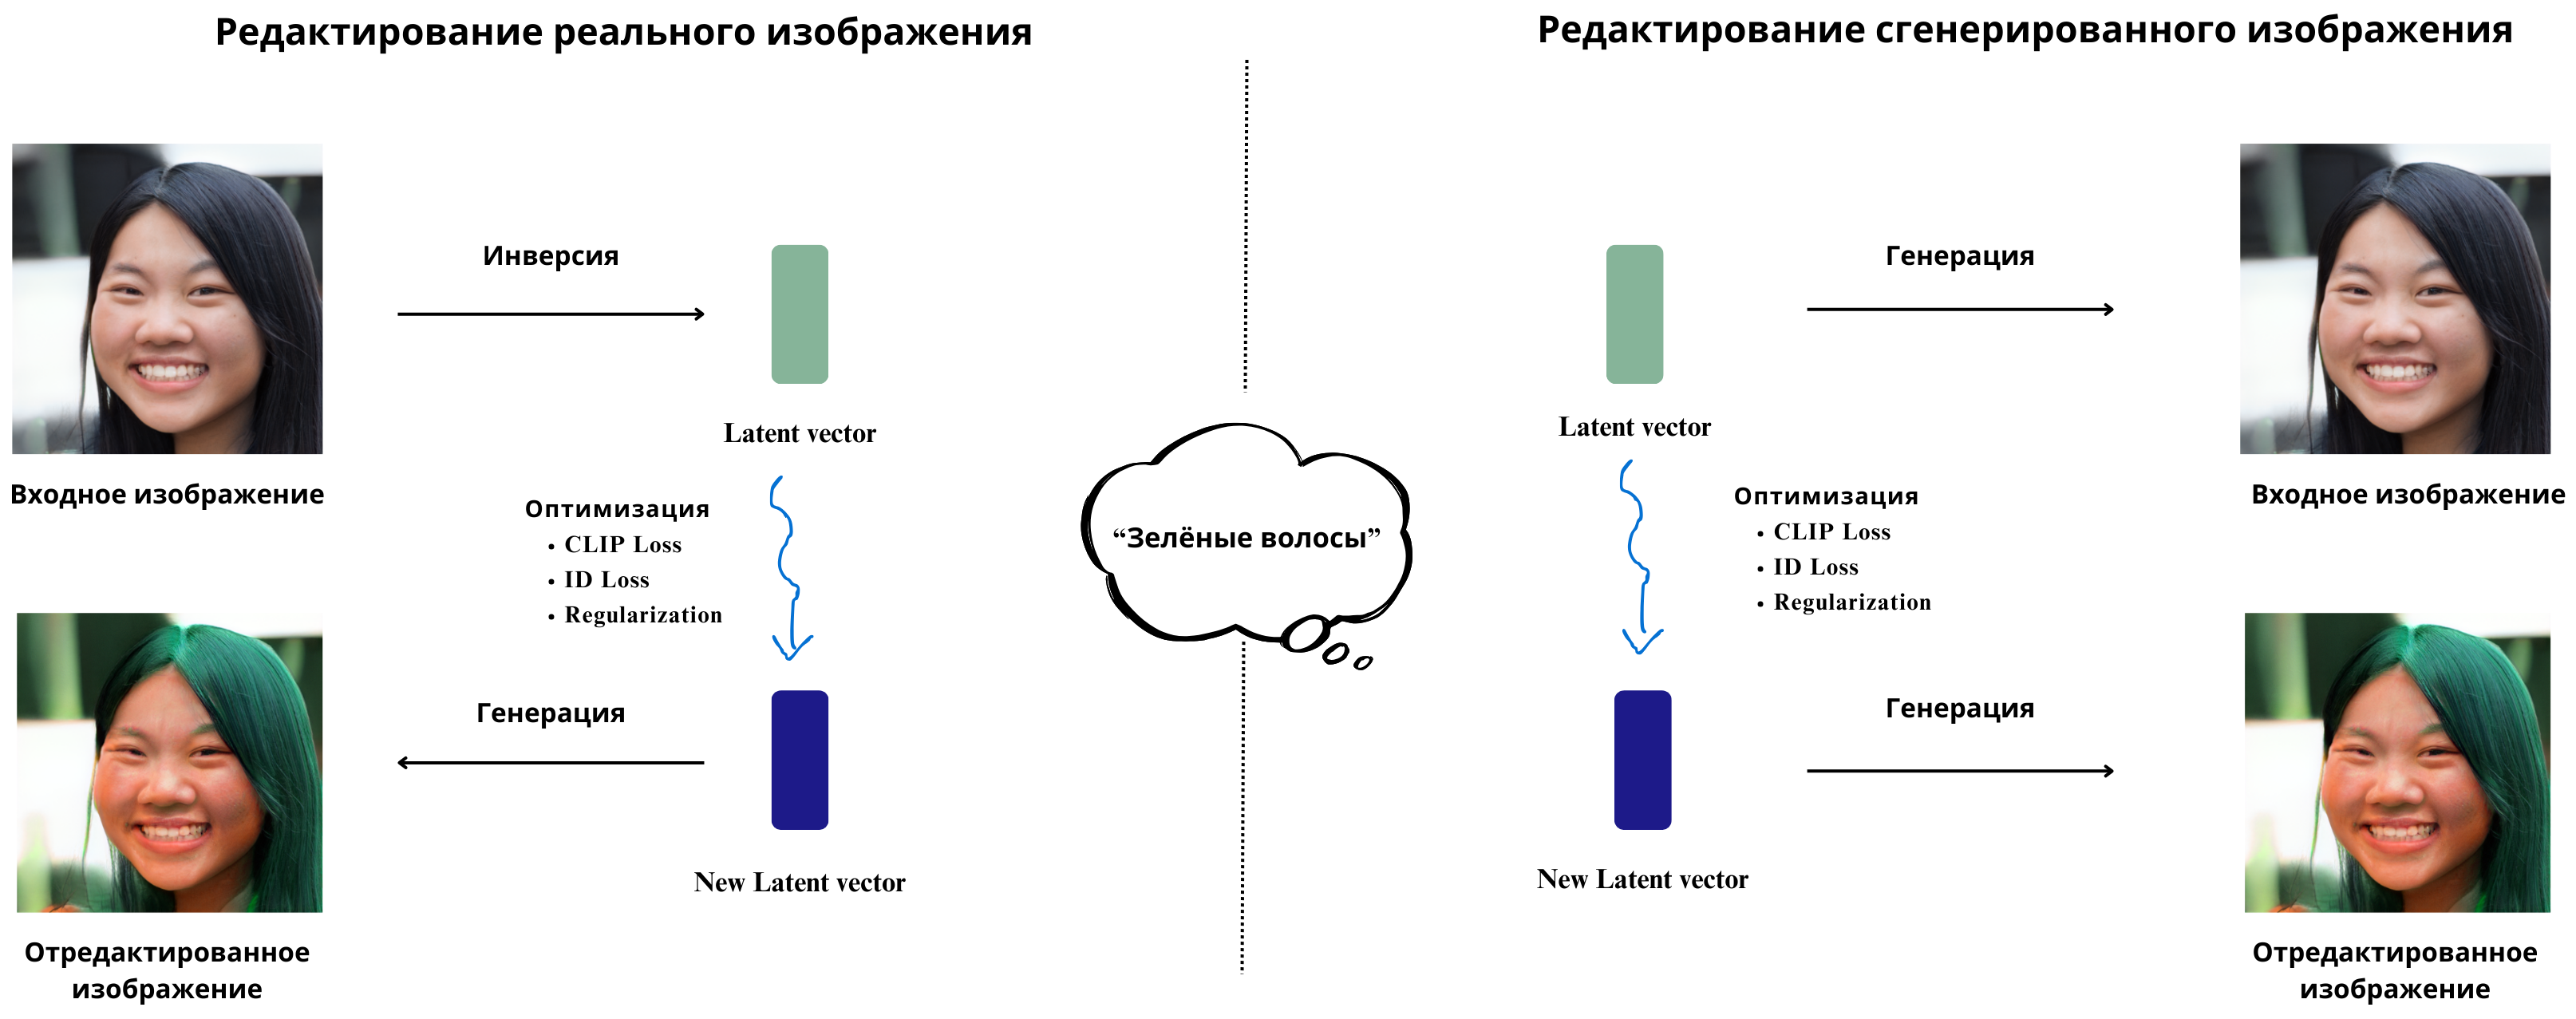

Наш план будет состоять в следующем:

1. Подготовка всех моделей для оптимизации

2. Реализация всех необходимых функций потерь:

  - CLIP Loss (1 балла)
  - ID Loss (1 балла)

3. Подготовка кода оптимизации (2 балла)

4. Выводы из полученных результатов (1 балл)

Давайте же попробуем написать код для этой оптимизации!

## Установка необходимых библиотек и подготовка окружения
Начнем с установки необходимых библиотек и клонирования репозитория StyleCLIP, чтобы использовать его методы.

In [1]:
# Установка необходимых библиотек

# Установка зависимостей
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
# Установка дополнительных библиотек
!pip install Ninja

# Импорт нужных библиотек
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ehi1j7uk
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ehi1j7uk
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=fe2b4857be6fa6b6727e309b0526e18352083c5d55831509385fca5ab5c05de7
  Stored in directory: /tmp/pip-ephem-wheel-cache-xlmotuq4/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 14.1 MB/s eta 0:00:00


In [2]:
# Clone the repository (using the .git suffix for explicitness)
!git clone https://github.com/rosinality/stylegan2-pytorch.git

# Change the current working directory to the cloned repository
%cd stylegan2-pytorch/


Cloning into 'stylegan2-pytorch'...
remote: Enumerating objects: 395, done.
remote: Total 395 (delta 0), reused 0 (delta 0), pack-reused 395 (from 1)
Receiving objects: 100% (395/395), 122.51 MiB | 15.71 MiB/s, done.
Resolving deltas: 100% (205/205), done.
/content/stylegan2-pytorch


In [3]:
# Будем работать с конкретным сидом
torch.manual_seed(345)

## Основная идея статьи


Как уже было сказано, мы хотим редактировать изображение с помощью текста. Для этого будем использовать [CLIP](https://paperswithcode.com/method/clip) модель для некоторого гайданса в процессе оптимизации.

Задачу мы хотим построить следующим образом: имея исходный латентный вектор $w \in W$ мы хотим оптимизировать его под текстовый запрос $t$. Давайте подгрузм нашу модель и сгенерируем картинку для дальнейшей оптимизации.

Для работы со StyleGAN-2 нам для начала нужно скачать модель. Для скачивания мы используем следующий код:

In [4]:
# Ensure gdown is installed for downloading files from Google Drive
!pip install gdown

import gdown

# downloads StyleGAN's weights and facial recognition network weights
ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT', '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL']
for file_id in ids:
  # Construct the Google Drive download URL
  url = f'https://drive.google.com/uc?id={file_id}'
  # Use gdown to download the file
  # gdown automatically infers the filename from the Google Drive API
  gdown.download(url, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT
From (redirected): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT&confirm=t&uuid=b3b482b1-ab67-4fd1-9968-3eedd6789858
To: /content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt
100%|██████████| 381M/381M [00:11<00:00, 33.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL
From (redirected): https://drive.google.com/uc?id=1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL&confirm=t&uuid=f810f29f-f608-491b-a421-d7eeaa85ecf9
To: /content/stylegan2-pytorch/model_ir_se50.pth
100%|██████████| 175M/175M [00:05<00:00, 32.5MB/s]


In [5]:
# Зададим девайс: cuda или cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
# Зададим сид
seed = 3456
torch.manual_seed(seed)

In [7]:
# Параметры генератора
size = 1024  # Размер изображения
latent_dim = 512  # Размер латентного пространства
n_mlp = 8  # Количество слоев MLP
channel_multiplier = 2
ckpt = '/content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt'  # Путь к весам StyleGAN2

In [8]:
from model import Generator #работает только на cuda

In [9]:
# Инициализация генератора
generator = Generator(size, latent_dim, n_mlp, channel_multiplier=channel_multiplier).to(device)
generator.eval()  # Режим валидации
checkpoint = torch.load(ckpt)
generator.load_state_dict(checkpoint["g_ema"])  # Подгрузка весов

print("Генератор StyleGAN2 загружены.")

Генератор StyleGAN2 загружены.


### Функция для генерации изображения из латентного вектора
Эта функция генерирует изображение из латентного вектора $z \in Z$ ($w \in W$), что нам пригодится для визуализации процесса редактирования.

/content/stylegan2-pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.9.0+cu126. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


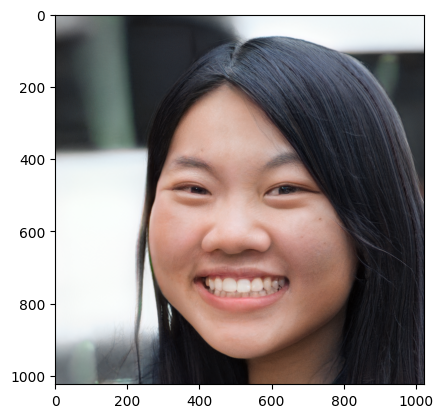

In [10]:
# Сгенерируем изображение
latent_z = torch.randn(10000, 512, device=device) # Z noise
latent_z_generated = latent_z.mean(0, keepdim=True)

with torch.no_grad():
  target_img, _ = generator([latent_z_generated], input_is_latent=False)

# Визуализируйте изначальную картинку
# YOUR CODE IS HERE
target_img_tensor = target_img.detach() # Сохраняем изображение как целевое для инверсии
# Визуализируем нашу картинку. Дополнительно переводим изображение из [-1, 1] -> [0, 1], предварительно отрезав значения больше 1 и меньше -1
plt.imshow((target_img.cpu().detach()[0].permute(1,2,0).clip(-1, 1) + 1)/2)
plt.show()

## Задача оптимизации

Теперь давайте подронее сформулируем задачу оптимизации.

Нам необходимо следующее:

- Отредактированное изображение соответствует текстовому запросу

- Сохраняет identity изначального человека.

Авторы предлагают следующий лосс для оптимизации:

$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$

Давайте разберёмся с каждой частью подробнее.

### CLIP loss

Начнём мы с CLIP loss.

 $D_{\text{CLIP}}$ — косинусное расстояние между эмбеддингами [CLIP](https://habr.com/ru/articles/539312/) для двух аргументов.

$$D_{\text{CLIP}}(G(w), t) = 1 - \frac{\langle E_{\text{CLIP}}(G(w)) \cdot E_{\text{CLIP}}(t) \rangle }{\|E_{\text{CLIP}}(G(w))\| \cdot \|E_{\text{CLIP}}(t)\|}$$


self.preprocess модели CLIP переключается на CPU, когда преобразует PyTorch tensor к PIL (Pillow) Image, однако Style GAN у меня на CPU не захотел подгружаться. Чтобы градиенты текли нужно использовать одно устройство, поэтому пропишем преобразования данных картинки в классе CLIPLoss руками

In [31]:
class CLIPLoss(torch.nn.Module):
    """
    Этот класс определяет пользовательскую функцию потерь на основе CLIP (Contrastive Language–Image Pre-training).
    Он измеряет сходство между изображением и текстовым описанием.
    """

    def __init__(self, stylegan_size=1024):
        """
        Инициализирует класс CLIPLoss.

        Args:
            opts: Объект, содержащий различные параметры, включая размер изображения StyleGAN.
        """
        super(CLIPLoss, self).__init__()
        # Загружаем предварительно обученную модель CLIP и функцию предварительной обработки
        self.model, self.preprocess = clip.load("ViT-B/32", device="cuda")
        self.device = "cuda" if torch.cuda.is_available() else "cpu" # Store the actual device used by CLIP model
        # но вообще данный ноутбук работает только на cuda
        self.model.eval() # Ensure CLIP model is in evaluation mode

        self.upsample = torch.nn.Upsample(scale_factor=7)
        self.avg_pool = torch.nn.AvgPool2d(kernel_size=stylegan_size // 32)

        # Extract CLIP's target image size and normalization parameters from its preprocess transforms
        self.clip_resize_size = 224 # Default for ViT-B/32
        self.normalize_mean = None
        self.normalize_std = None

        for t in self.preprocess.transforms:
            if isinstance(t, transforms.Resize):
                self.clip_resize_size = t.size
            if isinstance(t, transforms.Normalize):
                self.normalize_mean = torch.tensor(t.mean, device=self.device).view(1, -1, 1, 1)
                self.normalize_std = torch.tensor(t.std, device=self.device).view(1, -1, 1, 1)

        if self.normalize_mean is None or self.normalize_std is None:
            raise ValueError("CLIP preprocess transform does not contain Normalize. Cannot extract mean/std.")

    def forward(self, image, text):
        """
        Вычисляет потери CLIP между изображением и текстом.

        Args:
            image: Входной тензор изображения.
            text: Тензор текстового описания.

        Returns:
            Значение потерь CLIP.
        """
        # Меняем размерность изображения для получения нужного разрешения для CLIP
        image = self.avg_pool(self.upsample(image))
        # Вычислите косинусное расстояние d между эмбеддингами CLIP от картинки и текста и посчитаем loss = 1 - d

        # YOUR CODE IS HERE

        # Convert image from StyleGAN's [-1, 1] range to CLIP's expected [0, 1] range
        # This step is differentiable.
        image_0_1 = (image.clamp(-1, 1) + 1) / 2

        # Resize image to CLIP's expected input size (e.g., 224x224)
        # Use bicubic interpolation for better quality and differentiability
        img_clip_input = F.interpolate(image_0_1, size=self.clip_resize_size, mode='bicubic', align_corners=False)

        # Apply CLIP's normalization (mean and std) directly on the GPU tensor
        # This step is differentiable.
        img_clip_input = (img_clip_input - self.normalize_mean) / self.normalize_std

        # Get image embeddings from CLIP model
        image_features = self.model.encode_image(img_clip_input)

        # Normalize image embeddings
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Get text embeddings from CLIP model (assuming text_inputs is already tokenized and on device)
        text_features = self.model.encode_text(text_inputs)
        # Normalize text embeddings
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Calculate cosine similarity loss
        loss = 1 - torch.sum(image_features * text_features, dim=-1)

        return loss

In [32]:
clip_loss = CLIPLoss()

### ID loss

Для сохранения identity человека использует специально предобученную модель [ArcFace](https://arxiv.org/abs/1801.07698), которая по фотографии вычисляет некоторые характерные для человека embedding вектора. Затем нам необходимо посчитать косинусное расстояние между ожидаемым embedding вектором и тем, что получается в процессе оптимизации:

$$ L_{\text{ID}}(w) = 1 - \langle R(G(w_s)), R(G(w)) \rangle $$

Обратите внимание, что здесь не используется дополнительная нормировка


Давайте подгрузим нашу модель и реализуем желаемую функцию потерь.


### Подгрузка модели

Далее у нас будет подгрузка самой модели, позаимствованная из репозитория [StyleCLIP](https://github.com/orpatashnik/StyleCLIP/blob/main/models/facial_recognition/helpers.py). Вы можете более подробно ознакомиться с кодом этой модели ниже, но мы не будем заострять на ней внимание.


In [13]:
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Dropout, Sequential, Module

"""
Modified Backbone implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""
from collections import namedtuple
import torch
from torch.nn import Conv2d, BatchNorm2d, PReLU, ReLU, Sigmoid, MaxPool2d, AdaptiveAvgPool2d, Sequential, Module

"""
ArcFace implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""


class Flatten(Module):
	def forward(self, input):
		return input.view(input.size(0), -1)


def l2_norm(input, axis=1):
	norm = torch.norm(input, 2, axis, True)
	output = torch.div(input, norm)
	return output


class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])):
	""" A named tuple describing a ResNet block. """


def get_block(in_channel, depth, num_units, stride=2):
	return [Bottleneck(in_channel, depth, stride)] + [Bottleneck(depth, depth, 1) for i in range(num_units - 1)]


def get_blocks(num_layers):
	if num_layers == 50:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=4),
			get_block(in_channel=128, depth=256, num_units=14),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 100:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=13),
			get_block(in_channel=128, depth=256, num_units=30),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 152:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=8),
			get_block(in_channel=128, depth=256, num_units=36),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	else:
		raise ValueError("Invalid number of layers: {}. Must be one of [50, 100, 152]".format(num_layers))
	return blocks


class SEModule(Module):
	def __init__(self, channels, reduction):
		super(SEModule, self).__init__()
		self.avg_pool = AdaptiveAvgPool2d(1)
		self.fc1 = Conv2d(channels, channels // reduction, kernel_size=1, padding=0, bias=False)
		self.relu = ReLU(inplace=True)
		self.fc2 = Conv2d(channels // reduction, channels, kernel_size=1, padding=0, bias=False)
		self.sigmoid = Sigmoid()

	def forward(self, x):
		module_input = x
		x = self.avg_pool(x)
		x = self.fc1(x)
		x = self.relu(x)
		x = self.fc2(x)
		x = self.sigmoid(x)
		return module_input * x


class bottleneck_IR(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False), PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False), BatchNorm2d(depth)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class bottleneck_IR_SE(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR_SE, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False),
			PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False),
			BatchNorm2d(depth),
			SEModule(depth, 16)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class Backbone(Module):
	def __init__(self, input_size, num_layers, mode='ir', drop_ratio=0.4, affine=True):
		super(Backbone, self).__init__()
		assert input_size in [112, 224], "input_size should be 112 or 224"
		assert num_layers in [50, 100, 152], "num_layers should be 50, 100 or 152"
		assert mode in ['ir', 'ir_se'], "mode should be ir or ir_se"
		blocks = get_blocks(num_layers)
		if mode == 'ir':
			unit_module = bottleneck_IR
		elif mode == 'ir_se':
			unit_module = bottleneck_IR_SE
		self.input_layer = Sequential(Conv2d(3, 64, (3, 3), 1, 1, bias=False),
									  BatchNorm2d(64),
									  PReLU(64))
		if input_size == 112:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 7 * 7, 512),
			                               BatchNorm1d(512, affine=affine))
		else:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 14 * 14, 512),
			                               BatchNorm1d(512, affine=affine))

		modules = []
		for block in blocks:
			for bottleneck in block:
				modules.append(unit_module(bottleneck.in_channel,
										   bottleneck.depth,
										   bottleneck.stride))
		self.body = Sequential(*modules)

	def forward(self, x):
		x = self.input_layer(x)
		x = self.body(x)
		x = self.output_layer(x)
		return l2_norm(x)


def IR_50(input_size):
	"""Constructs a ir-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_101(input_size):
	"""Constructs a ir-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_152(input_size):
	"""Constructs a ir-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_SE_50(input_size):
	"""Constructs a ir_se-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_101(input_size):
	"""Constructs a ir_se-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_152(input_size):
	"""Constructs a ir_se-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir_se', drop_ratio=0.4, affine=False)
	return model

### ID loss

Теперь непосредственно реализуем нашу функцию потерь.

In [14]:
import torch
from torch import nn


class IDLoss(nn.Module):
    def __init__(self, model_weights, device='cuda'):
        super(IDLoss, self).__init__()
        print('Loading ResNet ArcFace')
        # Загружаем предобученную модель ResNet ArcFace для извлечения признаков лица.
        # input_size: размер входного изображения (112x112).
        self.facenet = Backbone(input_size=112, num_layers=50, drop_ratio=0.6, mode='ir_se')
        # Загружаем веса предобученной модели
        self.facenet.load_state_dict(torch.load(model_weights, weights_only=True))
        self.pool = torch.nn.AdaptiveAvgPool2d((256, 256))
        self.face_pool = torch.nn.AdaptiveAvgPool2d((112, 112))
        self.facenet.eval()
        # Перемещаем модель ArcFace на GPU, если доступен.
        self.facenet.to(device)


    def extract_feats(self, x):
        # Функция для извлечения эмбеддингов лица из изображения x.
        # Если размер изображения не 256x256, изменяем его с помощью пулинга.
        if x.shape[2] != 256:
            x = self.pool(x)
        # Обрезаем центральную область изображения (35:223, 32:220), содержащую лицо.
        x = x[:, :, 35:223, 32:220]
        # Изменяем размер обрезанной области до 112x112 с помощью пулинга.
        x = self.face_pool(x)
        # Извлекаем эмбеддинги лица с помощью модели ArcFace.
        x_feats = self.facenet(x)
        # Возвращаем извлеченные эмбеддинги.
        return x_feats

    def forward(self, y_hat, y):
        # Функция для вычисления ID Loss.
        # y_hat: отредактированное изображение.
        # y: исходное изображение.
        n_samples = y.shape[0]
        # Извлекаем признаки лица из исходного изображения.
        # YOUR CODE IS HERE
        y_feats = self.extract_feats(y)#.detach()

        # Извлекаем признаки лица из отредактированного изображения.
        # YOUR CODE IS HERE
        y_hat_feats = self.extract_feats(y_hat)#.detach()

        # Не забудьте сделать detach()!
        # YOUR CODE IS HERE


        # Считаем наш лосс
        similarity = 0
        for i in range(n_samples):
            # Считаем косинусное расстояние между признаками исходного и
            # оптимизируемого изображения
            # YOUR CODE IS HERE
            similarity += F.cosine_similarity(y_feats[i], y_hat_feats[i], dim=0)

        loss = 1 - similarity

        return loss

In [15]:
# Загрузим нашу модель ArcFace
model_path = "/content/stylegan2-pytorch/model_ir_se50.pth"
id_loss = IDLoss(model_path, device)

Loading ResNet ArcFace


## Инициализация латентного вектора и текстовой подсказки
Определим латентный вектор
𝑊
W для исходного изображения и преобразуем текстовую подсказку в вектор с помощью CLIP, что будет служить нашей целью для редактирования.

## Оптимизация для редактирования изображения
Реализуем оптимизацию, используя Adam. На каждом шаге обновляется латентный вектор $w \in W$ для минимизации потерь CLIP, пока результат не будет похож на текстовую подсказку.

Основной псевдокод оптимизации представлен ниже:

```python

for step in range(num_steps):  # <----------- итерируемся по датасету несколько раз
    torch.cuda.empty_cache() # <------------- очищаем кэш модели
    optimizer.zero_grad()  # <------------- обуляем градиенты модели
    image, _ = generator([latent], input_is_latent=True, randomize_noise=False)  # <------------- получаем картинку из StyleGAN-2
    loss = clip_loss + l2_lambda * l2_loss + id_lambda * id_loss
    loss.backward()  # <------------------- считаем градиенты
    optimizer.step()  # <------------------ делаем шаг градиентного спуска
    if convergence:  # <------------------- в случае сходимости выходим из цикла
        break
```

Где полная функция потерь считается по формуле:
$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$

Дополнительно сохраните значения лосс функций для дальнейшей визуализации.


In [16]:
# Подготавливаем текстовый промпт для оптимизации, который будет направлять изменение изображения.
prompt = "a person with green hair"

# Токенизируем промпт с помощью CLIP tokenizer и перемещаем на устройство (CPU или GPU).
# clip.tokenize: функция из библиотеки CLIP для токенизации текста.
text_inputs = torch.cat([clip.tokenize(prompt)]).to(device)

In [17]:
# Подготовим папку для сохранения результатов
import os
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

Работать предлагаем в пространстве $W$, давайте преобразуем наш вектор в styleSpace

In [187]:
# Получаем w-вектор из z-вектора с помощью mapping network генератора.
with torch.no_grad():
  latent_w = generator.style(latent_z_generated)

latent = latent_w.detach().clone()#.unsqueeze(0) #added unsqueeze(0)
latent.requires_grad = True

In [58]:
%matplotlib inline

inversion_generated_z/Step [25/25], Loss: 0.66748046875


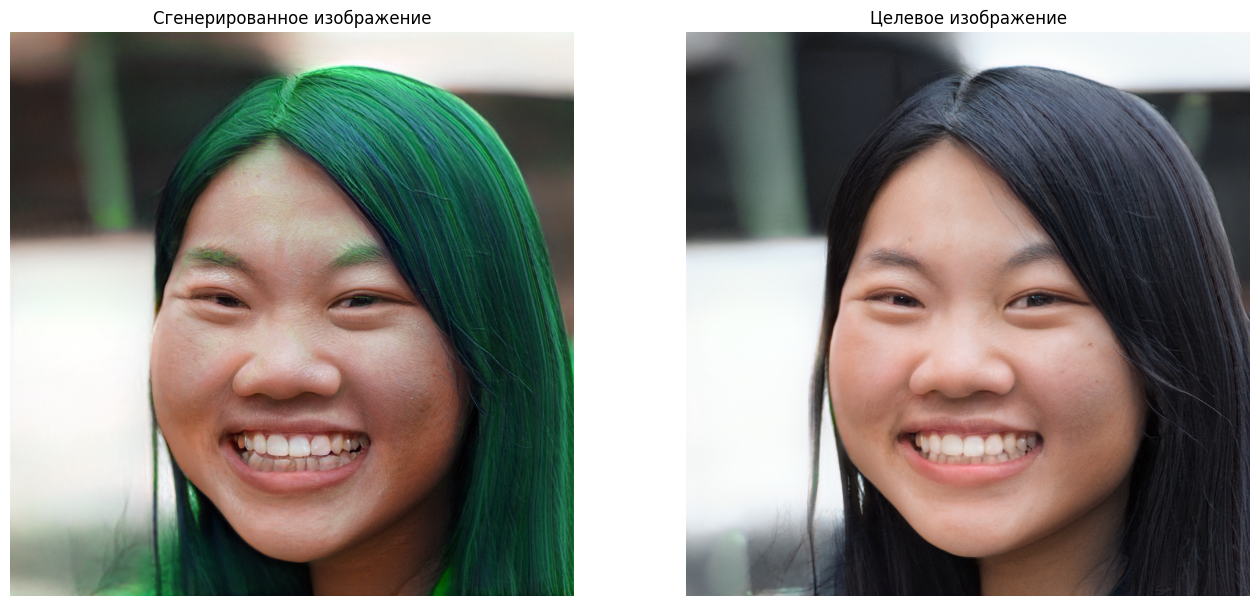

In [188]:
# Оптимизация для редактирования с помощью CLIP

# Создадим оптимизатор Adam
# YOUR CODE IS HERE
optimizer = torch.optim.Adam([latent], lr=0.08)
# для более быстрой сходимости
# А также выберем скедулер
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)  # Плавное снижение скорости обучения

num_steps = 25  # количество шагов оптимизации
# уменьшили колличество шагов в 4 раза по сравнению с изначально предложенным в ноутбуке
l2_lambda = 0.00000008 # коэффициент для L2 регуляризации
# уменьшили в 10*5 раз по сравнению с изначально предложенным в ноутбуке
#  It's like saying, "Change this specific thing, but don't break everything else in the process."
id_lambda = 0.5  # коэффициент для identity loss
# увеличили в 500 раз по сравнению с изначально предложенным в ноутбуке
#  to directly address changes in face color due to identity shift, increase id_lambda


# Не забудьте сохранять лоссы для дальнейшей визуализации!
losses = {'clip': [],
          'l2': [],
          'id': [],
          'all': []
          }

# Напишем наш цикл оптимизации:

for step in range(num_steps):
    # YOUR CODE IS HERE
    torch.cuda.empty_cache()
    optimizer.zero_grad()  # Обнуление градиентов перед новой итерацией

    generated_img, _ = generator([latent], input_is_latent = True, randomize_noise = False)  # Генерация изображения из W-вектора

    # loss
    clip_loss_value = clip_loss(generated_img,text_inputs)
    l2 = torch.sum((generated_img - target_img_tensor)**2)
    id_loss_value = id_loss(generated_img,target_img_tensor)

    # Суммарный loss
    loss = clip_loss_value + l2_lambda * l2 + id_lambda * id_loss_value

    loss.backward()  # Обратное распространение ошибки

    losses['clip'].append(clip_loss_value.item())
    losses['l2'].append(l2_lambda * l2.item())
    losses['id'].append(id_lambda * id_loss_value.item())
    losses['all'].append(loss.item())

    optimizer.step()  # Обновление параметров W-вектора

    # Визуализация и вывод потерь
    if (step+1) % 25 == 0:  # Каждые 25 шагов
        print(f"inversion_generated_z/Step [{step+1}/{num_steps}], Loss: {losses['all'][-1]}")  # Вывод текущих потерь
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))  # Создание подграфиков для визуализации

        # Визуализация сгенерированного изображения
        axs[0].imshow((generated_img.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")  # Заголовок для сгенерированного изображения
        axs[0].axis('off')  # Отключение осей

        # Визуализация целевого изображения
        axs[1].imshow((target_img.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2)
        axs[1].set_title("Целевое изображение")  # Заголовок для целевого изображения
        axs[1].axis('off')  # Отключение осей
        plt.show()

Визуализируйте лоссы в зависимости от step

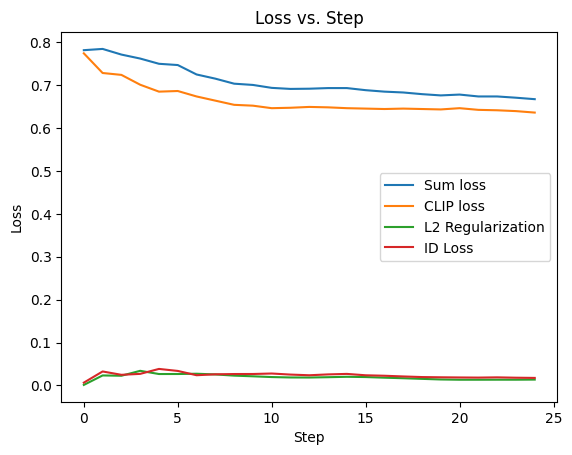

In [189]:
# YOUR CODE IS HERE
# Визуализируем функци потерь в процессе оптимизации
plt.plot(losses['all'], label='Sum loss')
plt.plot(losses['clip'], label='CLIP loss')
plt.plot(losses['l2'], label='L2 Regularization')
plt.plot(losses['id'], label='ID Loss')
plt.title("Loss vs. Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

Лоссы не показывают динамику обучения, зато помогли увидить, что коэфициент регуляризации L2 надо сильно снизить, а коэфициент для ID loss увеличить

Сохряним результаты!

In [191]:
import os

filename = prompt

# Save the latents to a .pt file.
latent_path = os.path.join(save_dir, filename + ".pt")
torch.save(latent, latent_path)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
save_image(generated_img, image_path)


print(f"Ваше изображение и латенты успешно сохранены в папке {save_dir}")

Ваше изображение и латенты успешно сохранены в папке results


### Выводы

Напишите ваши выводы, что получилось, что нет, почему получилось, почему нет.

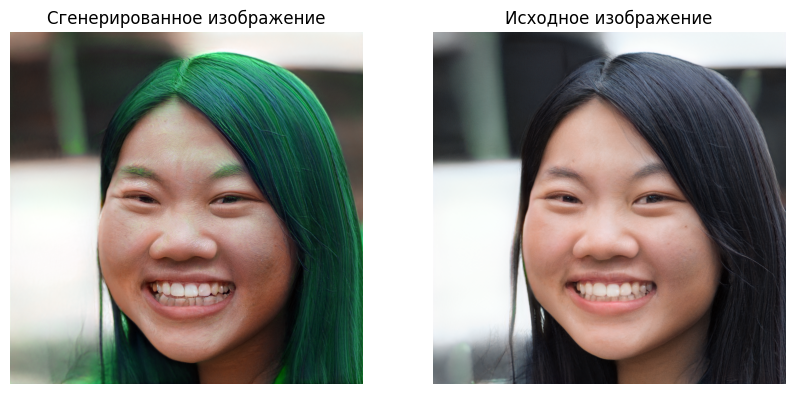

In [190]:
# Посмотрим на конечный результат
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow((generated_img.cpu().detach().squeeze().permute(1, 2, 0) + 1) / 2)
axs[0].set_title("Сгенерированное изображение")
axs[0].axis('off')

axs[1].imshow((target_img_tensor.cpu().squeeze().permute(1, 2, 0).clip(-1,1) + 1) / 2)
axs[1].set_title("Исходное изображение") # Целевое заменил на Исходное
axs[1].axis('off')

plt.show()

Все получилось, ей даже идет